<a href="https://colab.research.google.com/github/RamMG21/Master-Ciberseguridad-USAL/blob/main/taller_socmint_ira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller de SOCMINT: anatomía de una granja de trolls

**Máster en Ciberseguridad · Inteligencia de Fuentes Abiertas en Redes Sociales**

En este taller vamos a investigar casi **3 millones de tweets** publicados entre 2012 y 2018 por cuentas vinculadas a la **Internet Research Agency (IRA)**, la "fábrica de trolls" de San Petersburgo señalada por el Congreso y el Fiscal Especial de EE. UU. por interferir en las elecciones presidenciales de 2016.

No vamos a leer tweets uno a uno. Vamos a hacer lo que hace un analista de SOCMINT: **buscar patrones** que delaten una operación coordinada.

| Bloque | Pregunta de investigación | Técnica |
|---|---|---|
| 1 | ¿Qué tenemos entre manos? | Exploración de datos |
| 2 | ¿Cuándo actuaban y qué dispara su actividad? | Series temporales, detección de picos |
| 3 | ¿Se comportan como personas o como una oficina? | Huella horaria / *pattern of life* |
| 4 | ¿Qué narrativas empujaban? ¿A ambos bandos? | Análisis de hashtags |
| 5 | ¿A quién intentaban influir? | Análisis de menciones |
| 6 | ¿Se pueden descubrir los grupos sin conocer las etiquetas? | Similitud + detección de comunidades (Louvain y Leiden) |
| 7 | ¿Hay pruebas de coordinación? | Detección de *copypasta* y red de co-publicación |

**Duración estimada:** 2,5–3 horas · **Requisitos:** Python ≥ 3.10, ~3 GB de RAM libre, ~1,2 GB de disco.

**¿Google Colab?** Funciona tal cual: sube el notebook (*Archivo → Subir cuaderno*) y ejecuta *Entorno de ejecución → Ejecutar todas*. La primera celda instala lo que falte y la descarga de datos tarda un par de minutos. El almacenamiento de Colab es temporal: en cada sesión nueva se vuelven a descargar los datos.

---

### ⚖️ Antes de empezar: ética y marco legal

* Los datos fueron publicados por **FiveThirtyEight** (2018) a partir del trabajo de **Darren Linvill y Patrick Warren** (Clemson University). Las cuentas fueron identificadas por Twitter y entregadas al *House Intelligence Committee* de EE. UU.; **todas están suspendidas**.
* Aun así, los tweets **mencionan a personas reales**. En SOCMINT, que un dato sea público **no** significa que cualquier tratamiento sea legítimo: principio de **minimización** (RGPD art. 5.1.c), **finalidad** y **proporcionalidad**. Aquí trabajamos con un fin docente y de investigación sobre una operación de influencia ya documentada.
* Un análisis de coordinación produce **indicios, no pruebas**. Atribuir una cuenta a un actor estatal exige corroboración por varias fuentes. Lo discutiremos al final.

## 0. Preparación del entorno

Instalamos solo las librerías que falten (en Google Colab: `pyvis`, `leidenalg` e `igraph`; el resto ya viene instalado).

In [ ]:
import importlib.util, subprocess, sys

NECESARIAS = {"pandas": "pandas", "pyarrow": "pyarrow", "networkx": "networkx", "matplotlib": "matplotlib",
              "seaborn": "seaborn", "sklearn": "scikit-learn", "pyvis": "pyvis", "igraph": "igraph", "leidenalg": "leidenalg"}
faltan = [pip for mod, pip in NECESARIAS.items() if importlib.util.find_spec(mod) is None]
if faltan:
    print("Instalando:", ", ".join(faltan))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltan])
EN_COLAB = "google.colab" in sys.modules
print("Entorno listo", "(Google Colab)" if EN_COLAB else "")

Entorno listo 


In [ ]:
import re
import urllib.request
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_colwidth", 130)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# Un color fijo por categoría para que todos los gráficos sean coherentes
COLORES = {
    "RightTroll": "#d62728", "LeftTroll": "#1f77b4", "NewsFeed": "#2ca02c",
    "HashtagGamer": "#9467bd", "Fearmonger": "#ff7f0e", "Commercial": "#8c564b",
    "NonEnglish": "#7f7f7f", "Unknown": "#c7c7c7",
}
SALIDAS = Path("salidas"); SALIDAS.mkdir(exist_ok=True)

### 0.1 Descarga de los datos

El dataset está en GitHub repartido en 13 CSV (~1,1 GB): <https://github.com/fivethirtyeight/russian-troll-tweets>

La primera vez se descargan y se guarda una copia compacta en formato **Parquet** (columnas tipadas, carga en segundos). Las siguientes ejecuciones leen directamente esa copia.

In [ ]:
DATA = Path("data"); DATA.mkdir(exist_ok=True)
URL = "https://raw.githubusercontent.com/fivethirtyeight/russian-troll-tweets/master/IRAhandle_tweets_{}.csv"
CACHE = DATA / "ira_tweets.parquet"
COLUMNAS = ["author", "content", "region", "language", "publish_date", "following",
            "followers", "post_type", "account_type", "account_category", "tweet_id"]

if not CACHE.exists():
    partes = []
    for i in range(1, 14):
        f = DATA / f"IRAhandle_tweets_{i}.csv"
        if not f.exists():
            print("Descargando", f.name, "...")
            urllib.request.urlretrieve(URL.format(i), f)
        partes.append(pd.read_csv(f, usecols=COLUMNAS, dtype=str))
    df = pd.concat(partes, ignore_index=True)
    df["publish_date"] = pd.to_datetime(df["publish_date"], format="%m/%d/%Y %H:%M")
    df[["following", "followers"]] = df[["following", "followers"]].apply(pd.to_numeric, errors="coerce")
    df["content"] = df["content"].fillna("")
    df.to_parquet(CACHE)
    del partes

df = pd.read_parquet(CACHE)
print(f"{len(df):,} tweets · {df['author'].nunique():,} cuentas · "
      f"{df['publish_date'].min():%d/%m/%Y} → {df['publish_date'].max():%d/%m/%Y}")

2,946,207 tweets · 2,843 cuentas · 02/02/2012 → 30/05/2018


## 1. Exploración: ¿qué tenemos entre manos?

Lo primero en cualquier investigación es **conocer la fuente**: qué campos hay, qué significan y qué sesgos pueden tener.

In [ ]:
df.sample(5, random_state=7)

,author,content,region,language,publish_date,following,followers,post_type,account_type,account_category,tweet_id
2740785,TRAYNESHACOLE,She is so damn RACIST!!! aaand she's blocked! ✊�✊�✊� BOOST THIS TO MAKE IT VIRAL!! APPLAUSE TO DERAY #Blm @deray https://t.co...,United States,English,2016-04-29 16:49:00,4996,4269,RETWEET,Left,LeftTroll,726091126956916736
802271,DANISSTRS,BREAKING: Harvey Weinstein Just Called it Quits! https://t.co/qaoAhF6yke,Unknown,English,2017-10-22 09:24:00,992,1613,NaN,Right,RightTroll,922030885175783424
997991,EVANNGHARTR,RT USAlivestrong: DanielStevens12 ProudExCon Sheckyi libertyschild1 StuartBirdman2 BadJuJu19 KnucklDraginSam TRUMP… https://t....,Unknown,English,2017-08-09 17:09:00,2911,1544,NaN,Right,RightTroll,895331153841750016
273708,BATONROUGEVOICE,3 arrested in Phoenix gay bar robberies https://t.co/Ch5FWHDr2F,United States,English,2016-10-01 16:11:00,2385,3125,NaN,local,NewsFeed,782251615788998657
1999278,NYAN_MEOW_MEOW,'@pretty_bastard0 ���',United Arab Emirates,French,2015-08-28 21:10:00,2391,4870,NaN,Russian,NonEnglish,637371778369777664


Campos clave:

| Campo | Significado |
|---|---|
| `author` | *handle* de la cuenta troll |
| `content` | texto del tweet |
| `publish_date` | fecha y hora de publicación (sin zona horaria documentada, ver bloque 3) |
| `post_type` | vacío = tweet original, `RETWEET` o `QUOTE_TWEET` |
| `followers` / `following` | seguidores y seguidos en el momento de la captura |
| `account_category` | **etiqueta asignada por Linvill y Warren** tras leer manualmente las cuentas |

Las categorías de Linvill y Warren describen **"personajes"** (*personas*) que la IRA fabricaba:

| Categoría | Personaje |
|---|---|
| **RightTroll** | Votante conservador pro-Trump, "patriota", nacionalista |
| **LeftTroll** | Activista progresista, a menudo centrado en identidad racial (BLM) y anti-Hillary |
| **NewsFeed** | Falso medio de noticias local (`@OnlineMemphis`, `@TodayPittsburgh`...) |
| **HashtagGamer** | Cuentas que juegan a "juegos de hashtags" para ganar seguidores |
| **Fearmonger** | Difunden bulos sobre crisis inventadas (intoxicaciones, explosiones...) |
| **Commercial** | Spam comercial |
| **NonEnglish** | Cuentas en otros idiomas, sobre todo ruso (audiencia doméstica) |

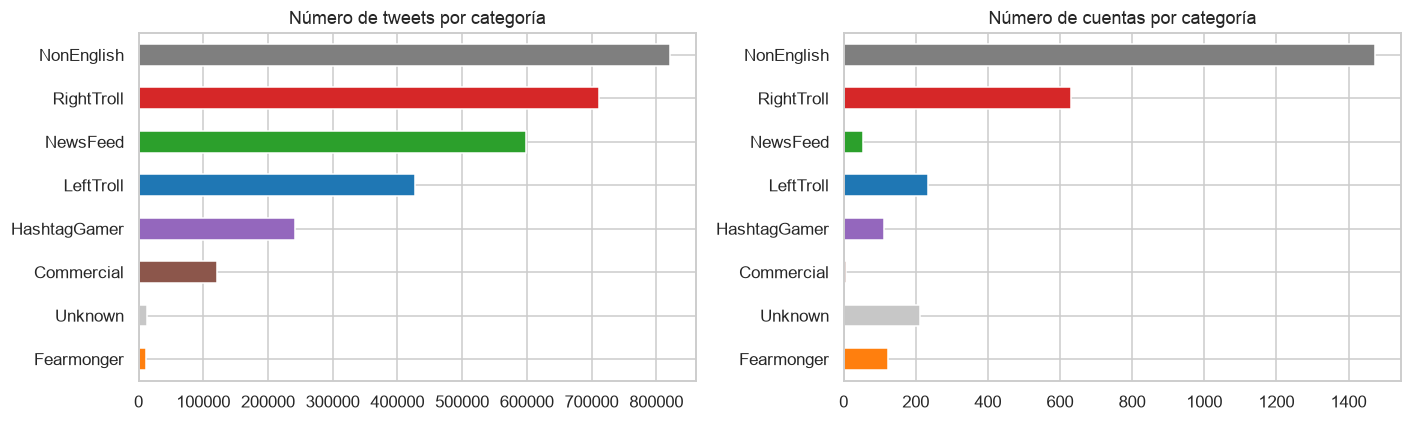

,tweets,cuentas,tweets_por_cuenta
account_category,,,
NonEnglish,820803,1473,557.0
RightTroll,711668,630,1130.0
NewsFeed,598226,54,11078.0
LeftTroll,427141,233,1833.0
HashtagGamer,241786,112,2159.0
Commercial,121904,6,20317.0
Unknown,13539,211,64.0
Fearmonger,11140,124,90.0


In [ ]:
resumen = (df.groupby("account_category")
             .agg(tweets=("content", "size"), cuentas=("author", "nunique"))
             .sort_values("tweets", ascending=False))
resumen["tweets_por_cuenta"] = (resumen["tweets"] / resumen["cuentas"]).round(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["tweets", "cuentas"]):
    resumen[col].plot.barh(ax=ax, color=[COLORES[c] for c in resumen.index])
    ax.invert_yaxis(); ax.set_title(f"Número de {col} por categoría"); ax.set_ylabel("")
plt.tight_layout(); plt.show()
resumen

In [ ]:
df["language"].value_counts().head(10)

language
English               2116867
Russian                610943
German                  86983
Ukrainian               38669
Italian                 18063
Serbian                  9480
Uzbek                    9334
Bulgarian                9236
LANGUAGE UNDEFINED       8320
Arabic                   7588
Name: count, dtype: int64

> **Observa:** uno de cada cinco tweets está en ruso, y más de una cuarta parte no está en inglés. La IRA no solo actuaba hacia fuera: también hacía propaganda para el público ruso y ucraniano.
>
> A partir de aquí nos centramos en las cinco categorías **en inglés dirigidas a EE. UU.**: `RightTroll`, `LeftTroll`, `NewsFeed`, `HashtagGamer` y `Fearmonger`.

In [ ]:
CATS = ["RightTroll", "LeftTroll", "NewsFeed", "HashtagGamer", "Fearmonger"]
en = df[df["account_category"].isin(CATS)].copy()
print(f"{len(en):,} tweets de {en['author'].nunique():,} cuentas")

1,989,961 tweets de 1,153 cuentas


### ✏️ Ejercicio 1
¿Cuáles son las **3 cuentas más activas** de cada categoría? ¿Y las que tienen más seguidores? Busca alguna de ellas en Google o en noticias: varias llegaron a ser citadas por medios de comunicación y políticos reales.

<details><summary>Solución</summary>

```python
# Más activas
en.groupby("account_category")["author"].value_counts().groupby(level=0).head(3)

# Más seguidas (máximo de seguidores registrado por cuenta)
(en.groupby(["account_category", "author"])["followers"].max()
   .sort_values(ascending=False).groupby(level=0).head(3).sort_index())
```
Ejemplos famosos: `TEN_GOP` (se hacía pasar por el Partido Republicano de Tennessee, con más de 145.000 seguidores), `JENN_ABRAMS` (una supuesta bloguera conservadora citada por medios como CNN o *The Washington Post*) o `CRYSTAL1JOHNSON`.
</details>

In [ ]:
# Tu código aquí

## 2. ¿Cuándo actuaban? Series temporales y picos

Una operación de influencia no publica a ritmo constante: **responde a una agenda**. Los picos de actividad son el primer hilo del que tirar.

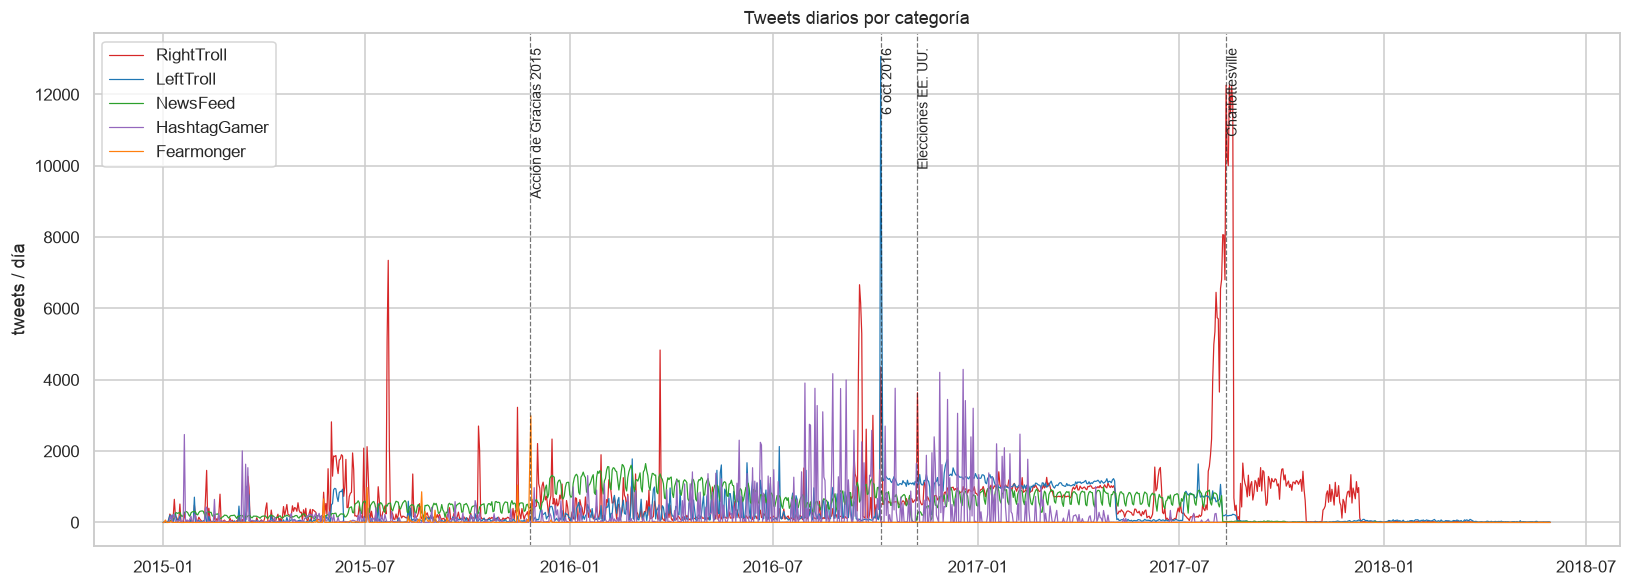

In [ ]:
diario = (en.groupby([pd.Grouper(key="publish_date", freq="D"), "account_category"])
            .size().unstack(fill_value=0).loc["2015-01-01":"2018-05-31"])

EVENTOS = {
    "2015-11-26": "Acción de Gracias 2015",
    "2016-10-06": "6 oct 2016",
    "2016-11-08": "Elecciones EE. UU.",
    "2017-08-12": "Charlottesville",
}

fig, ax = plt.subplots(figsize=(15, 5.5))
for c in CATS:
    ax.plot(diario.index, diario[c], lw=0.8, color=COLORES[c], label=c)
for fecha, texto in EVENTOS.items():
    ax.axvline(pd.Timestamp(fecha), color="k", ls="--", lw=0.8, alpha=0.6)
    ax.text(pd.Timestamp(fecha), ax.get_ylim()[1] * 0.97, " " + texto, rotation=90, va="top", fontsize=9)
ax.set_title("Tweets diarios por categoría"); ax.set_ylabel("tweets / día"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

In [ ]:
# Los 3 días de máxima actividad de cada categoría
picos = (diario.stack().rename("tweets").reset_index()
           .sort_values("tweets", ascending=False)
           .groupby("account_category").head(3)
           .sort_values(["account_category", "tweets"], ascending=[True, False]))
picos

,publish_date,account_category,tweets
1650,2015-11-27,Fearmonger,2990
1645,2015-11-26,Fearmonger,1618
1590,2015-11-15,Fearmonger,1048
3591,2016-12-19,HashtagGamer,4292
3486,2016-11-28,HashtagGamer,4209
3006,2016-08-24,HashtagGamer,4171
3222,2016-10-06,LeftTroll,13067
3227,2016-10-07,LeftTroll,6217
2767,2016-07-07,LeftTroll,2128
2168,2016-03-09,NewsFeed,1650


### 2.1 Caso de estudio: el 6 de octubre de 2016

Las cuentas **LeftTroll** normalmente publican unos cientos de tweets diarios. El 6 de octubre de 2016 publican **más de 13.000**. Al día siguiente, el 7 de octubre, WikiLeaks empezó a publicar los correos de John Podesta, jefe de campaña de Hillary Clinton, y salió a la luz la grabación de *Access Hollywood* de Trump.

¿Qué estaban haciendo exactamente esas cuentas?

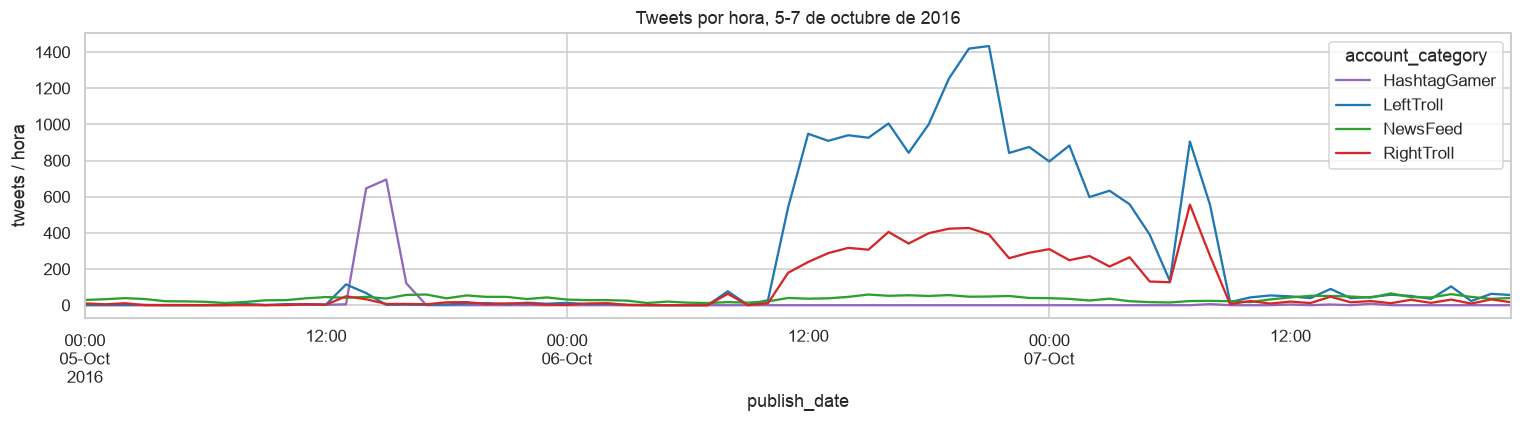

Cuentas LeftTroll activas ese día: 91

Tipo de publicación:
post_type
RETWEET        12983
ORIGINAL          81
QUOTE_TWEET        3
Name: count, dtype: int64


In [ ]:
ventana = en[(en["publish_date"] >= "2016-10-05") & (en["publish_date"] < "2016-10-08")]
por_hora = (ventana.groupby([pd.Grouper(key="publish_date", freq="h"), "account_category"])
                   .size().unstack(fill_value=0))

ax = por_hora.plot(figsize=(14, 4), color=[COLORES[c] for c in por_hora.columns], lw=1.5)
ax.set_title("Tweets por hora, 5-7 de octubre de 2016"); ax.set_ylabel("tweets / hora")
plt.tight_layout(); plt.show()

dia = ventana[(ventana["publish_date"].dt.date == pd.Timestamp("2016-10-06").date())
              & (ventana["account_category"] == "LeftTroll")]
print("Cuentas LeftTroll activas ese día:", dia["author"].nunique())
print("\nTipo de publicación:")
print(dia["post_type"].fillna("ORIGINAL").value_counts())

In [ ]:
print("Hashtags más frecuentes ese día:")
print(dia["content"].str.lower().str.findall(r"#\w+").explode().value_counts().head(12).to_string())
dia[["author", "publish_date", "content"]].sample(10, random_state=1)

Hashtags más frecuentes ese día:
content
#nowplaying           270
#thefourhorsemen      153
#theartofwar          153
#t                    153
#follow               152
#dagr8fm              131
#hurricanematthew     115
#blacklivesmatter      94
#np                    83
#hiphop                80
#ifwt                  65
#nationalpoetryday     59


,author,publish_date,content
328986,BIGBOYSNEED,2016-10-06 14:37:00,what's my name Canada ?? #LeafsBySnoop #tweed https://t.co/8o078mAMVx
1575898,LAGONEHOE,2016-10-06 13:41:00,"'@SheSeauxSaditty that was an interesting movie. i also loved Everyone Before Us, worth checking out if you haven't already'"
330940,BIGSEANBEAST,2016-10-06 13:00:00,Listen to the title track of the upcoming mashup album #TheFourHorsemen #TheArtOfWar ft #T… https://t.co/ENTjJICTXH https://t....
466297,CAMOSASEKO,2016-10-06 15:21:00,▶ A look at some of the most deadly US hurricanes https://t.co/kCDYRLagzM @CNSNews https://t.co/WkRvCZ6vMR
681580,CRYSTAL1JOHNSON,2016-10-06 00:15:00,"Just Remember: If There Is No Struggle, There Is No Progress! #BlackTwitter https://t.co/OUa6jBGqeB"
1360592,JANELPERKINSON,2016-10-06 16:00:00,'@RednaxalA @realDonaldTrump @LjtBoathook @HillaryClinton He never proposed a Muslim ban post-candidacy. Meme debunked. #fail'
1280151,ILOVESARAHRICH,2016-10-06 21:01:00,Greatness all the way to the finish line. ��� https://t.co/Gi2LBT2fRr
2839006,WILLISBONNERR,2016-10-06 22:08:00,Stream DDARK DARK HORSE 2 MIXTAPE https://t.co/ptwcBTkGp7
1386499,JAVONHIDP,2016-10-06 22:45:00,'@sherylunderwood I love your hair today. Remember the date in case you want to share the details'
474229,CANNONSHER,2016-10-06 21:49:00,"I think I found my new, favorite ice cream. Way to step up @benandjerrys. https://t.co/Gyu8OFJNom"


> **Discusión:** casi todo son **retweets masivos de contenido banal** (música, *lifestyle*, noticias locales), concentrados en unas pocas horas. ¿Qué hipótesis se os ocurren?
> * ¿Inflar la actividad de las cuentas para ganar visibilidad (*audience building*) justo antes de una fecha clave?
> * ¿Ruido para enterrar otros contenidos?
> * ¿Una tarea programada que se ejecutó de golpe?
>
> En SOCMINT es fundamental **separar el hallazgo** (pico anómalo y sincronizado) **de la interpretación** (que siempre requiere más fuentes). La coincidencia temporal con la filtración **no prueba causalidad**.

### ✏️ Ejercicio 2
Las cuentas **Fearmonger** tienen su máximo histórico el **26-27 de noviembre de 2015** (Acción de Gracias). Averigua qué bulo estaban difundiendo.

<details><summary>Solución</summary>

```python
fm = en[(en["account_category"] == "Fearmonger")
        & (en["publish_date"].dt.date.astype(str).isin(["2015-11-26", "2015-11-27"]))]
print(fm["content"].str.lower().str.findall(r"#\w+").explode().value_counts().head(10))
fm["content"].sample(10, random_state=0)
```
Es la campaña **#KochFarms**: el bulo de que los pavos de una marca real estaban envenenados y habían intoxicado a familias en Acción de Gracias. Un ejemplo de manual de desinformación diseñada para generar pánico.
</details>

In [ ]:
# Tu código aquí

## 3. ¿Personas o una oficina? La huella horaria (*pattern of life*)

Los usuarios reales tuitean más por la tarde-noche y **más en fin de semana**. Una "granja" con empleados por turnos deja otra huella: actividad que **sigue el horario laboral** y que **baja en fin de semana**.

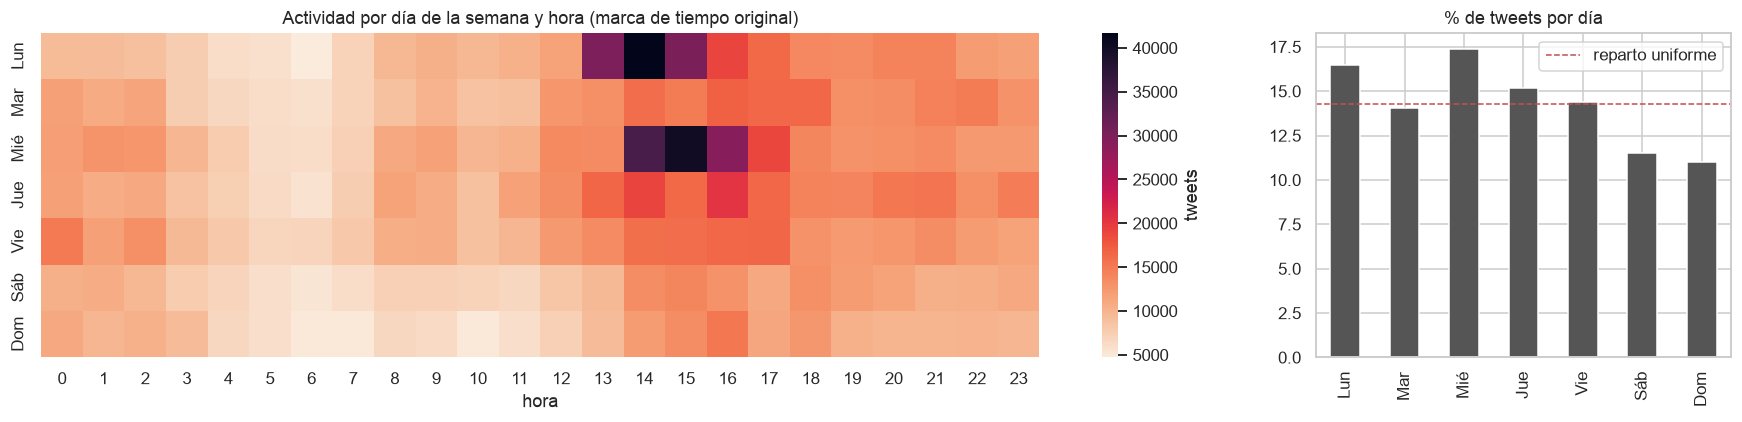

In [ ]:
DIAS = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
matriz = pd.crosstab(en["publish_date"].dt.dayofweek, en["publish_date"].dt.hour)
matriz.index = DIAS

fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"width_ratios": [3, 1]})
sns.heatmap(matriz, cmap="rocket_r", ax=axes[0], cbar_kws={"label": "tweets"})
axes[0].set_title("Actividad por día de la semana y hora (marca de tiempo original)")
axes[0].set_xlabel("hora"); axes[0].set_ylabel("")
(matriz.sum(axis=1) / matriz.sum().sum() * 100).plot.bar(ax=axes[1], color="#555")
axes[1].axhline(100 / 7, color="r", ls="--", lw=1, label="reparto uniforme")
axes[1].set_title("% de tweets por día"); axes[1].legend()
plt.tight_layout(); plt.show()

> **Observa:**
> * El **sábado y el domingo** concentran solo un ~11 % de los tweets cada uno, frente al ~14 % que correspondería a un reparto uniforme. Es lo contrario de lo que se espera de aficionados a la política que tuitean en su tiempo libre.
> * Hay **bloques muy oscuros los lunes y miércoles entre las 13 y las 16 h**: alguien publica grandes lotes siempre a la misma hora. Parece trabajo planificado.
>
> **Cuidado con la zona horaria:** la documentación del dataset no indica en qué zona están las marcas de tiempo. Si fueran UTC, las 9:00 de Moscú/San Petersburgo serían las 6:00 en el gráfico. Comprobar la zona horaria de una fuente es una tarea básica del analista y un error frecuente.

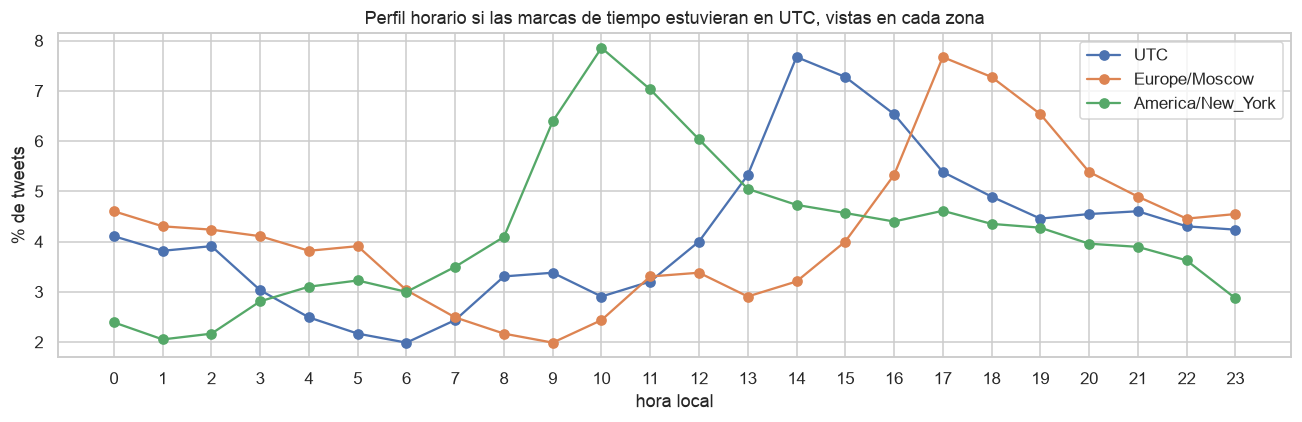

In [ ]:
# Mismo perfil horario bajo distintas hipótesis de zona horaria
perfiles = {}
for tz in ["UTC", "Europe/Moscow", "America/New_York"]:
    horas = en["publish_date"].dt.tz_localize("UTC").dt.tz_convert(tz).dt.hour
    perfiles[tz] = horas.value_counts(normalize=True).sort_index() * 100

ax = pd.DataFrame(perfiles).plot(figsize=(12, 4), marker="o", lw=1.5)
ax.set_xticks(range(24)); ax.set_xlabel("hora local"); ax.set_ylabel("% de tweets")
ax.set_title("Perfil horario si las marcas de tiempo estuvieran en UTC, vistas en cada zona")
plt.tight_layout(); plt.show()

### ✏️ Ejercicio 3
1. Repite el mapa de calor **solo para RightTroll** y **solo para LeftTroll**. ¿Son parecidas las huellas? ¿Qué te sugiere que dos "bandos" políticos opuestos tengan el mismo horario?
2. Calcula el porcentaje de tweets en fin de semana **por cuenta** (para cuentas con ≥ 500 tweets) y dibuja su histograma. ¿Hay cuentas que **nunca** publican en fin de semana?

<details><summary>Solución</summary>

```python
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, c in zip(axes, ["RightTroll", "LeftTroll"]):
    sub = en[en["account_category"] == c]
    m = pd.crosstab(sub["publish_date"].dt.dayofweek, sub["publish_date"].dt.hour, normalize="all")
    m.index = DIAS
    sns.heatmap(m, cmap="rocket_r", ax=ax); ax.set_title(c)
plt.tight_layout(); plt.show()

finde = en.assign(finde=en["publish_date"].dt.dayofweek >= 5).groupby("author").agg(
    n=("finde", "size"), pct_finde=("finde", "mean"))
finde = finde[finde["n"] >= 500]
finde["pct_finde"].mul(100).hist(bins=40)
plt.axvline(200 / 7, color="r", ls="--"); plt.xlabel("% tweets en fin de semana"); plt.show()
finde.sort_values("pct_finde").head(10)
```
</details>

In [ ]:
# Tu código aquí

## 4. ¿Qué narrativas empujaban? Hashtags

Los hashtags son la "etiqueta" con la que una campaña se inserta en una conversación. Extraemos todos los hashtags y comparamos las categorías.

In [ ]:
en["hashtags"] = en["content"].str.lower().str.findall(r"#\w+")
ht = en[["author", "account_category", "hashtags"]].explode("hashtags").dropna(subset=["hashtags"])

top = {c: ht.loc[ht["account_category"] == c, "hashtags"].value_counts().head(12).index.tolist() for c in CATS}
pd.DataFrame(top)

,RightTroll,LeftTroll,NewsFeed,HashtagGamer,Fearmonger
0,#maga,#blacklivesmatter,#news,#todolistbeforechristmas,#kochfarms
1,#tcot,#nowplaying,#sports,#thingsyoucantignore,#turkey
2,#pjnet,#blacktwitter,#politics,#mustbebanned,#usda
3,#top,#staywoke,#world,#2016in4words,#foodpoisoning
4,#news,#soundcloud,#local,#igetdepressedwhen,#demndebate
5,#fakenews,#policebrutality,#topnews,#ihatepokemongobecause,#walmart
6,#ccot,#hiphop,#health,#alternativeacronyminterpretations,#ny
7,#mar,#blm,#business,#giftideasforpoliticians,#fsis
8,#trump,#news,#tech,#istartcryingwhen,#dogthanking
9,#topl,#rap,#entertainment,#rejecteddebatetopics,#demdebate


### 4.1 Atizar a los dos bandos

Una de las tácticas más conocidas de la IRA fue **polarizar**: no apoyar a un bando, sino **echar leña al fuego en ambos**. Si eso es cierto, deberíamos ver los mismos hashtags usados por los trolls de izquierda **y** de derecha.

In [ ]:
lr = ht[ht["account_category"].isin(["LeftTroll", "RightTroll"])]
compartidos = lr.groupby(["hashtags", "account_category"])["author"].nunique().unstack(fill_value=0)
compartidos["min_ambos"] = compartidos[["LeftTroll", "RightTroll"]].min(axis=1)
compartidos = compartidos.sort_values("min_ambos", ascending=False)
print("Nº de cuentas de cada bando que usan el hashtag:")
compartidos.head(15)

Nº de cuentas de cada bando que usan el hashtag:


account_category,LeftTroll,RightTroll,min_ambos
hashtags,,,
#blacklivesmatter,172,191,172
#gopdebate,116,245,116
#tcot,108,230,108
#blm,126,104,104
#stopthegop,106,101,101
#trump,101,245,101
#gop,99,198,99
#chicago,96,112,96
#1,91,112,91


In [ ]:
# ¿Cómo usa cada bando #BlackLivesMatter?
blm = en[en["hashtags"].map(lambda h: "#blacklivesmatter" in h)
         & en["account_category"].isin(["LeftTroll", "RightTroll"])
         & en["post_type"].isna()]
for c in ["LeftTroll", "RightTroll"]:
    print(f"\n==== {c} ====")
    for t in blm.loc[blm["account_category"] == c, "content"].sample(6, random_state=3):
        print("·", t[:200])


==== LeftTroll ====
· RT @AmyStephen: Slavery to Mass Incarceration https://t.co/3kvwwrVKDL Good presentation on realities of systemic racism. #BlackLivesMatter …
· In the 60's one broadcast galvanized the nation. Now cops gun down unarmed men on vid and it's a debate. #LaquanMcDonald #blacklivesmatter
· I need this T-shirt �✊�✊�✊� #blacklivesmatter https://t.co/JMdcRgjwep
· All SIX COUNTS! This is HUGE VICTORY! #GrandJuryWatch #AnthonyHill  #allsixcounts @deray #BlackLivesMatter https://t.co/2VDeXIuOyM
· November.  #BlackLivesMatter #FreddieGrayTrial  #PoliceViolence https://t.co/8OE9FW9kF7
· Six-year-old girl declines her birthday gifts for homeless, while the WH can’t decline its' toys for anyone in the country #blacklivesmatter https://t.co/3X3N42Mvts

==== RightTroll ====
· #FergusonRemembers At least 5 black women have died in police custody in July #BlackLivesMatter #PoliceBrutality
· Chris Rock Posts Cryptic #Oscars ‘#Blackout’ Tweet   https://t.co/KgSNplXmd7 #BLM #BlackLivesM

> **Discusión:** los LeftTroll se presentaban como activistas afroamericanos, y una parte de los RightTroll usaba el hashtag para atacar al movimiento. **La misma organización** alimentaba los dos lados del conflicto.
>
> Fíjate también en que **algunos tweets de RightTroll son en realidad pro-BLM**. ¿Error de etiquetado? ¿Cuentas que cambiaron de "personaje"? En el bloque 7 encontraremos textos idénticos publicados por cuentas de ambos bandos.

## 5. ¿A quién intentaban influir? Menciones

Las **menciones** (`@usuario`) indican a quién se dirigían los trolls: políticos, periodistas, activistas... Extraemos todas las menciones y comparamos los objetivos de cada bando.

In [ ]:
cuentas_ira = set(df["author"].str.lower())

men = en[["author", "account_category", "content"]].copy()
men["mencion"] = men["content"].str.lower().str.findall(r"@(\w{1,15})")
men = men.explode("mencion").dropna(subset=["mencion"])
men["a_otra_ira"] = men["mencion"].isin(cuentas_ira)

print(f"{len(men):,} menciones; {men['a_otra_ira'].mean():.1%} van a otras cuentas de la IRA")
(men[~men["a_otra_ira"]].groupby("account_category")["mencion"]
    .value_counts().groupby(level=0).head(6).rename("menciones").to_frame())

458,243 menciones; 1.6% van a otras cuentas de la IRA


menciones
account_category mencion                   
Fearmonger       drdeancdc               21
                 ramrajumd               20
                 unmc_drkhan             20
                 clever_dove             18
                 nycgetinsured           18
                 danielleofri            18
HashtagGamer     midnight              9039
                 giselleevns           1212
                 hashtagroundup         819
                 keshatedder            598
                 realdonaldtrump        525
                 tlcprincess            452
LeftTroll        youtube               2244
                 realdonaldtrump       2030
                 talibkweli            1926
                 josephjett            1067
                 potus                  904
                 deray                  853
NewsFeed         news                    99
                 petolucem               30
                 isis_hunters            29
                 m3t4_tr0n               19
                 realdonaldtrump         18
                 noon                    18
RightTroll       realdonaldtrump      10692
                 potus                 4119
                 hillaryclinton        3802
                 cnn                   2620
                 foxnews               2520
                 youtube               1580

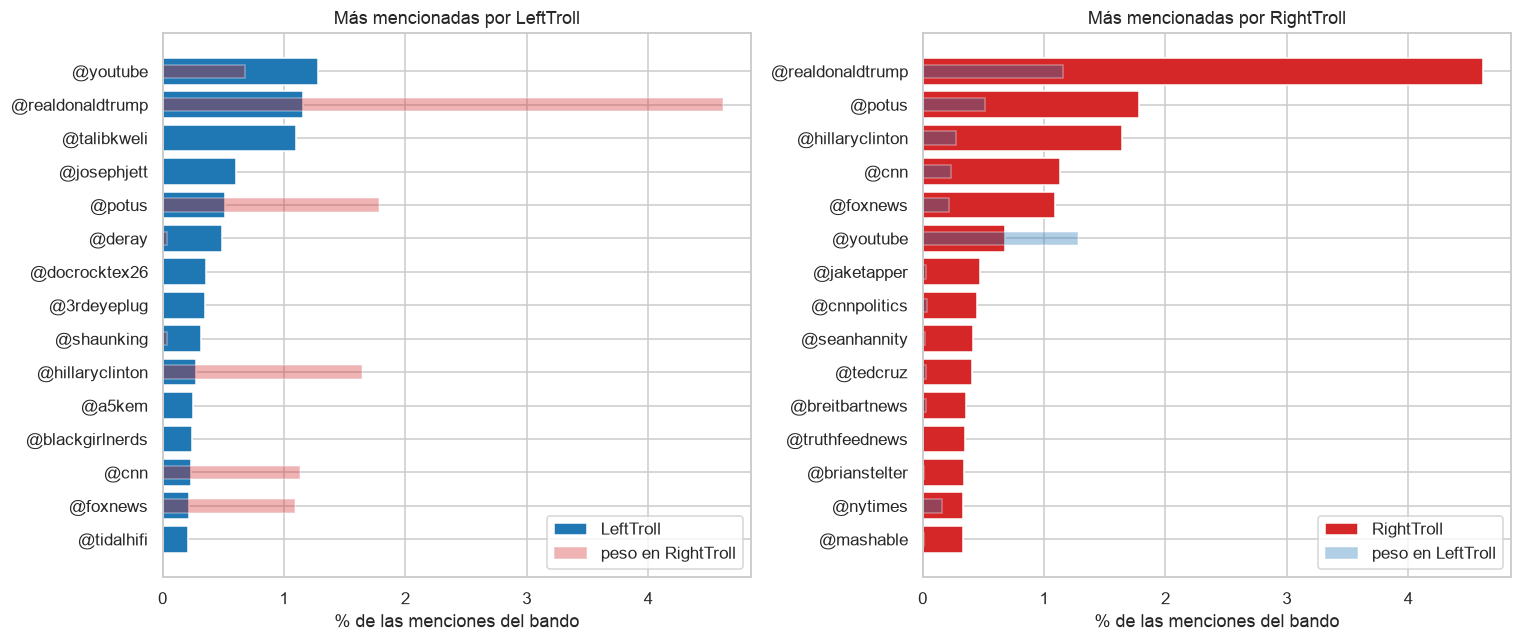

In [ ]:
# ¿A quién se dirige cada bando? Top 15 cuentas externas mencionadas por LeftTroll y por RightTroll
cat_de = en.groupby("author")["account_category"].first()
lr_men = men[men["account_category"].isin(["LeftTroll", "RightTroll"]) & ~men["a_otra_ira"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, c in zip(axes, ["LeftTroll", "RightTroll"]):
    sub = lr_men[lr_men["account_category"] == c]
    top_c = sub["mencion"].value_counts(normalize=True).head(15).mul(100)
    otro = "RightTroll" if c == "LeftTroll" else "LeftTroll"
    pct_otro = (lr_men[lr_men["account_category"] == otro]["mencion"]
                .value_counts(normalize=True).mul(100).reindex(top_c.index, fill_value=0))
    y = np.arange(len(top_c))
    ax.barh(y, top_c.values, color=COLORES[c], label=c)
    ax.barh(y, pct_otro.values, color=COLORES[otro], alpha=0.35, height=0.4, label=f"peso en {otro}")
    ax.set_yticks(y); ax.set_yticklabels("@" + top_c.index); ax.invert_yaxis()
    ax.set_xlabel("% de las menciones del bando"); ax.set_title(f"Más mencionadas por {c}"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

> **Observa:**
> * Los **LeftTroll** se dirigen a **activistas y artistas afroamericanos** (`@talibkweli`, `@deray`, `@shaunking`...), cuentas que los RightTroll casi no mencionan. Buscaban **integrarse en la comunidad** BLM y ganar credibilidad dentro de ella.
> * Los **RightTroll** mencionan sobre todo a Trump, Clinton y los grandes medios, y llama la atención la presencia de **periodistas de CNN** (`@jaketapper`, `@brianstelter`...). Veamos por qué en la celda siguiente.
> * Cada personaje tenía **su público objetivo**. Es un rasgo de una operación profesional: segmentar audiencias igual que haría una agencia de marketing.
>
> *Nota ética:* si en un ranking así aparece la cuenta de un particular sin relevancia pública, la anotamos como "objetivo" y **no seguimos investigándola**. No es necesario para el fin del análisis.

In [ ]:
# ¿Qué dicen los RightTroll cuando mencionan a periodistas de CNN?
cnn = en[(en["account_category"] == "RightTroll")
         & en["content"].str.contains(r"@(?:jaketapper|brianstelter|andersoncooper)\b", case=False, regex=True)]
spam = cnn[cnn["content"].str.contains("CNN is #FakeNews", case=False)]
print(f"{len(cnn):,} tweets de {cnn['author'].nunique()} cuentas mencionan a esos periodistas")
print(f"{len(spam) / len(cnn):.0%} son la misma plantilla 'CNN is #FakeNews!'. ¿Quién la publica?")
print(spam["author"].value_counts().head(3).to_string(), "\n")
for t in spam["content"].drop_duplicates().head(3):
    print("·", t, "\n")

1,107 tweets de 62 cuentas mencionan a esos periodistas
48% son la misma plantilla 'CNN is #FakeNews!'. ¿Quién la publica?
author
COVFEFENATIONUS    533 

· '@KerryHowley @brianstelter @CNN @CNNI @CNNPolitics @CNNSitRoom @WolfBlitzer @JakeTapper @TheLeadCNN @BrianStelter @AnaNavarro @DonLemon @VanJones68 @AndersonCooper @AC360 @JimAcosta  CNN IS #FAKENEWS! CNN IS #FAKENEWS! CNN IS #FAKENEWS! CNN IS #FAKENEWS! CNN IS #FAKENEWS! CNN IS #FAKENEWS!  #FAKENEWS #MAGA' 

· '@oceanmaniac @TruthFeedNews @CNNPolitics @CNN @CNNI @CNNPolitics @CNNSitRoom @WolfBlitzer @JakeTapper @TheLeadCNN @BrianStelter @AnaNavarro @DonLemon @VanJones68 @AndersonCooper @AC360 @JimAcosta  CNN IS #FAKENEWS! CNN IS #FAKENEWS! CNN IS #FAKENEWS! CNN IS #FAKENEWS! CNN IS #FAKENEWS! CNN IS #FAKENEWS!  #FAKENEWS #MAGA' 

· '@The_Trump_Train @realDonaldTrump @CNN @CNNI @CNNPolitics @CNNSitRoom @WolfBlitzer @JakeTapper @TheLeadCNN @BrianStelter @AnaNavarro @DonLemon @VanJones68 @AndersonCooper @AC360 @JimAcosta  CNN IS #FA

> Es un **bombardeo de menciones** (*mention bombing*): **una sola cuenta** (`COVFEFENATIONUS`) responde más de 500 veces a conversaciones ajenas con **la misma plantilla**, una lista fija de 15 cuentas de CNN y el mismo eslogan repetido. Así se llenan las notificaciones de los periodistas, se empuja `#FakeNews` y se "secuestran" conversaciones. Una persona no escribe 500 veces lo mismo: es **automatización**.
>
> **Lección metodológica:** un ranking de menciones no dice *por qué* se menciona a alguien. Hay que **leer los tweets** y comprobar **cuántas cuentas** hay detrás de un patrón. Aquí, la mitad de las menciones a esos periodistas venían de una única cuenta.

## 6. Descubrir los grupos sin conocer las etiquetas

Hasta ahora hemos usado las etiquetas de Linvill y Warren, que salieron de **leer a mano** miles de tweets. En una investigación real **no tendremos etiquetas**. ¿Podemos recuperar esos grupos de forma automática?

**Método:**
1. Representamos cada cuenta por su "perfil de hashtags" (vector **TF-IDF**).
2. Calculamos la **similitud coseno** entre todas las cuentas.
3. Unimos dos cuentas si su similitud supera un umbral, lo que da un grafo.
4. Aplicamos **Louvain**, un algoritmo que busca grupos densamente conectados entre sí (comunidades).
5. Comparamos las comunidades encontradas con las etiquetas manuales.

In [ ]:
perfil = (en.groupby("author")
            .agg(cat=("account_category", "first"), n=("content", "size"),
                 hashtags=("hashtags", lambda s: " ".join(h for lista in s for h in lista))))
perfil = perfil[(perfil["n"] >= 50) & (perfil["hashtags"].str.len() > 0)]
print(f"{len(perfil)} cuentas con ≥ 50 tweets y algún hashtag")

vec = TfidfVectorizer(token_pattern=r"\S+", min_df=3, sublinear_tf=True)
X = vec.fit_transform(perfil["hashtags"])
S = cosine_similarity(X)
np.fill_diagonal(S, 0)
print("Matriz de similitud:", S.shape)

814 cuentas con ≥ 50 tweets y algún hashtag


Matriz de similitud: (814, 814)


In [ ]:
UMBRAL = 0.3   # <- parámetro a explorar en el ejercicio

i, j = np.where(np.triu(S) > UMBRAL)
G = nx.Graph()
G.add_weighted_edges_from((perfil.index[a], perfil.index[b], S[a, b]) for a, b in zip(i, j))
nx.set_node_attributes(G, perfil["cat"].to_dict(), "cat")

comunidades = nx.community.louvain_communities(G, weight="weight", seed=42)
comunidades = sorted(comunidades, key=len, reverse=True)
com_de = {n: k for k, c in enumerate(comunidades) for n in c}
nx.set_node_attributes(G, com_de, "comunidad")

nodos = list(G.nodes)
ari = adjusted_rand_score([G.nodes[n]["cat"] for n in nodos], [com_de[n] for n in nodos])
print(G)
print(f"{len(comunidades)} comunidades · modularidad = {nx.community.modularity(G, comunidades):.2f} · ARI vs etiquetas = {ari:.2f}")

Graph with 727 nodes and 11579 edges
23 comunidades · modularidad = 0.68 · ARI vs etiquetas = 0.34


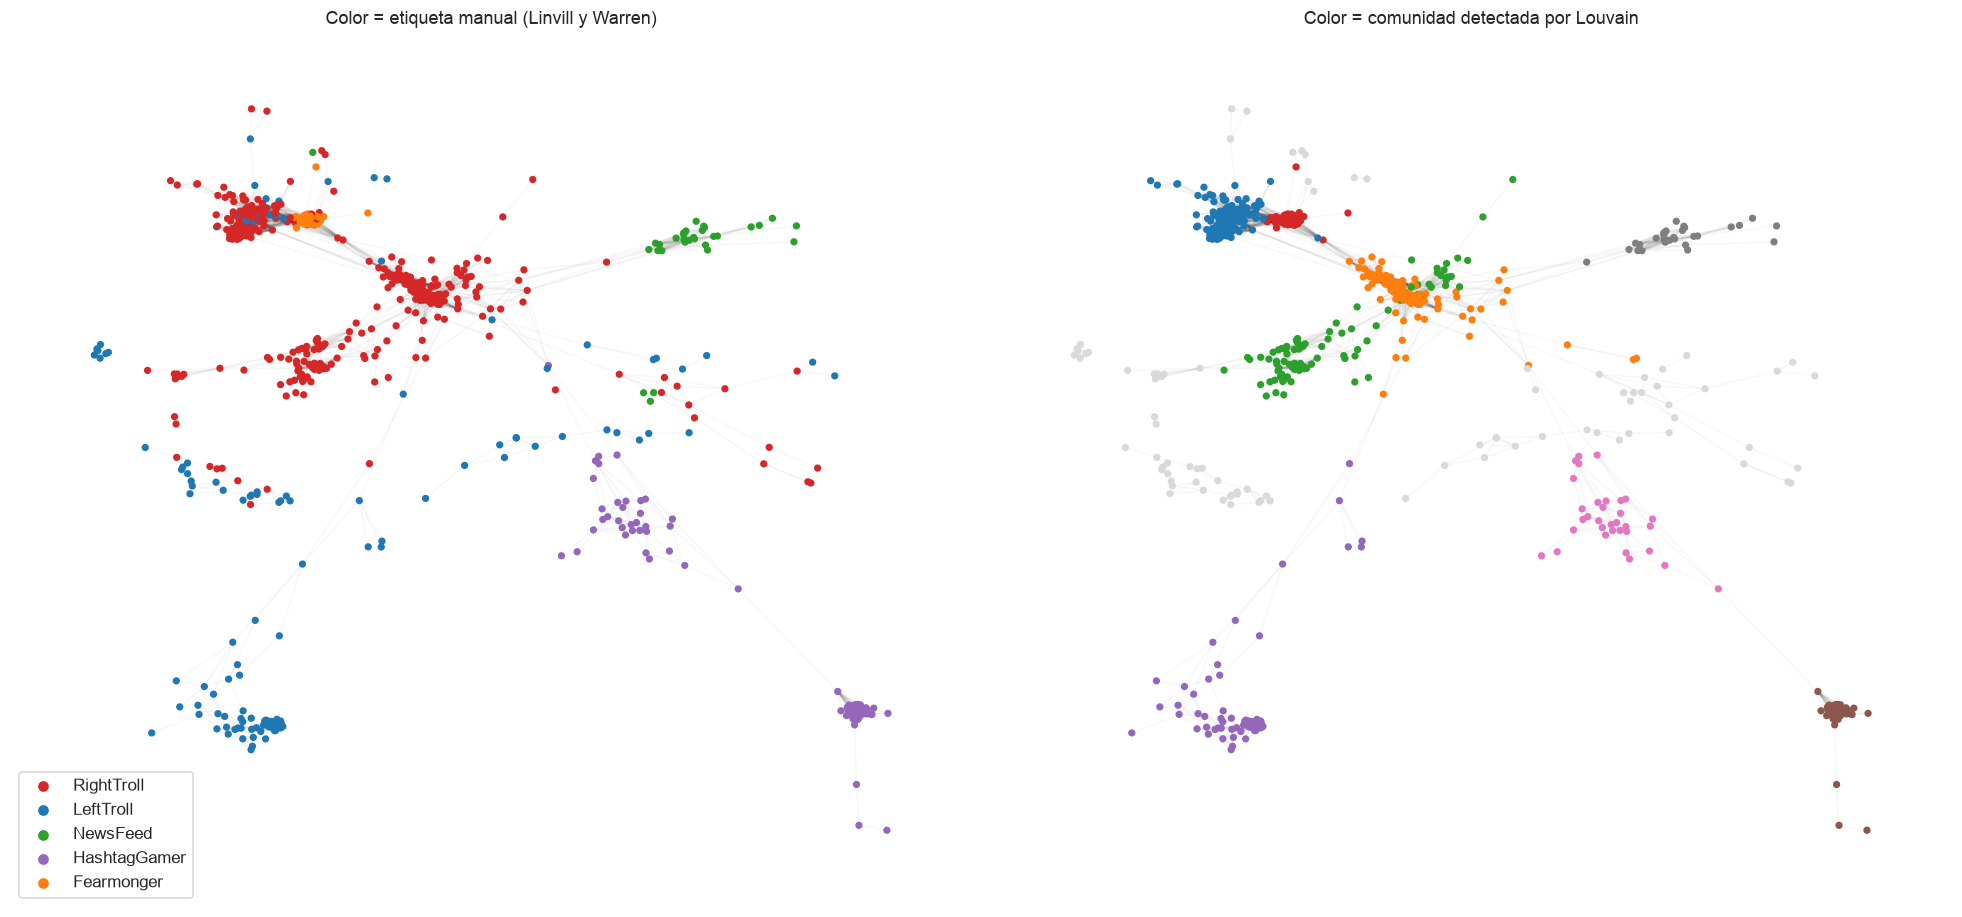

In [ ]:
pos = nx.spring_layout(G, k=0.08, iterations=60, seed=1, weight="weight")
TOPK = 8
paleta = sns.color_palette("tab10", TOPK)
col_com = [paleta[com_de[n]] if com_de[n] < TOPK else (0.85, 0.85, 0.85) for n in G]

fig, axes = plt.subplots(1, 2, figsize=(18, 8.5))
for ax, colores, titulo in [
    (axes[0], [COLORES[G.nodes[n]["cat"]] for n in G], "Color = etiqueta manual (Linvill y Warren)"),
    (axes[1], col_com, "Color = comunidad detectada por Louvain"),
]:
    nx.draw_networkx_edges(G, pos, alpha=0.03, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_size=14, node_color=colores, ax=ax)
    ax.set_title(titulo); ax.axis("off")
for c in CATS:
    axes[0].scatter([], [], c=COLORES[c], label=c)
axes[0].legend(loc="lower left")
plt.tight_layout(); plt.show()

In [ ]:
# ¿Qué hay dentro de cada comunidad? Composición y hashtags característicos
nombres_vocab = np.array(vec.get_feature_names_out())
filas = []
for k, c in enumerate(comunidades[:TOPK]):
    idx = [perfil.index.get_loc(n) for n in c]
    centroide = np.asarray(X[idx].mean(axis=0)).ravel()
    filas.append({
        "comunidad": k, "cuentas": len(c),
        "composición": perfil.loc[list(c), "cat"].value_counts().to_dict(),
        "hashtags característicos": " ".join(nombres_vocab[centroide.argsort()[::-1][:8]]),
    })
pd.DataFrame(filas).set_index("comunidad")

,cuentas,composición,hashtags característicos
comunidad,,,
0,136,"{'RightTroll': 122, 'LeftTroll': 14}",#islamkills #vegasgopdebate #gopdebate #stopthegop #demndebate #abcgopdebate #abcnews #demdebate
1,115,"{'RightTroll': 107, 'LeftTroll': 6, 'HashtagGamer': 1, 'Fearmonger': 1}",#pjnet #prayers4california #tcot #ccot #news #guns4ny #wakeupamerica #2a
2,99,{'RightTroll': 99},#altleft #ste #resistance #charlottesville #hurricaneharvey #takeaknee #maga #lockherup
3,98,"{'Fearmonger': 87, 'RightTroll': 11}",#kochfarms #usda #foodpoisoning #turkey #walmart #fsis #dogthanking #ny
4,68,"{'LeftTroll': 67, 'RightTroll': 1}",#staywoke #blacktwitter #blacklivesmatter #nowplaying #blackskinisnotacrime #wearhoodiefortrayvon #hiphop #dagr8fm
5,61,{'HashtagGamer': 61},#thingsyoucantignore #alternativeacronyminterpretations #giftideasforpoliticians #todolistbeforechristmas #mustbebanned #secon...
6,33,{'HashtagGamer': 33},#allwentwrongwhen #unitedstatesin3words #mypreworkoutroutine #reasoniamnotpresident #wasteamillionin3words #trumpcampaignsloga...
7,29,"{'NewsFeed': 28, 'RightTroll': 1}",#politics #news #sports #local #health #observationsatthemarathon #history #business


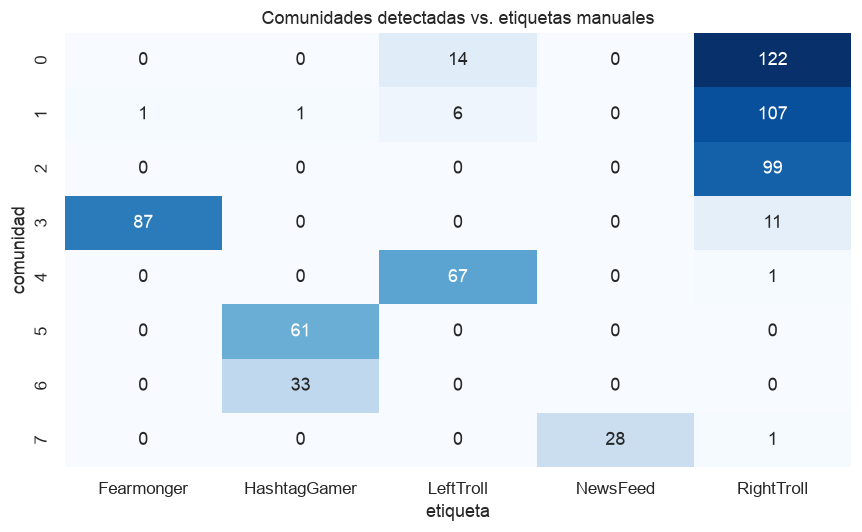

In [ ]:
tabla = pd.crosstab(pd.Series([com_de[n] for n in nodos], name="comunidad"),
                    pd.Series([G.nodes[n]["cat"] for n in nodos], name="etiqueta"))
tabla = tabla.loc[tabla.sum(axis=1).sort_values(ascending=False).index[:TOPK]]
plt.figure(figsize=(8, 5))
sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Comunidades detectadas vs. etiquetas manuales"); plt.tight_layout(); plt.show()

> **Interpretación:**
> * Sin decirle nada sobre las etiquetas, el algoritmo aísla en **comunidades propias** a HashtagGamer, Fearmonger (la campaña #KochFarms), NewsFeed y un núcleo de LeftTroll.
> * El ARI (*Adjusted Rand Index*: 1 = coincidencia perfecta, 0 = azar) es moderado. ¿Significa que el método funciona mal? Mira la tabla antes de responder.
> * Los **RightTroll se dividen en varias comunidades**. No es un error: son **subcampañas** distintas (primarias republicanas, MAGA, temas concretos...). El análisis automático aporta un nivel de detalle que la etiqueta manual no tiene.
> * Muchas cuentas LeftTroll quedan **dispersas en grupos pequeños** o dentro de comunidades RightTroll. **¿Error de etiquetado o cuentas que cambiaron de personaje?** La IRA reciclaba cuentas. Es un buen punto para investigar manualmente.

### ✏️ Ejercicio 4
1. Cambia `UMBRAL` a 0.2 y a 0.4. ¿Qué pasa con el número de comunidades, la modularidad y el ARI? ¿Qué umbral elegirías y por qué?
2. Busca las cuentas **LeftTroll que Louvain coloca en una comunidad mayoritariamente RightTroll**. Lee algunos de sus tweets. ¿Quién tiene razón, la etiqueta o el algoritmo?

<details><summary>Pista para el apartado 2</summary>

```python
mayoria = {k: perfil.loc[list(c), "cat"].mode()[0] for k, c in enumerate(comunidades)}
raras = [n for n in G if G.nodes[n]["cat"] == "LeftTroll" and mayoria[com_de[n]] == "RightTroll"]
en[en["author"].isin(raras[:3])].groupby("author")["content"].apply(lambda s: s.sample(5, random_state=0).tolist())
```
Verás cuentas progresistas que comentaban **en contra** los debates republicanos (`#VegasGOPDebate`, `#GOPDebate`). Los hashtags agrupan por **tema de conversación**, no por **postura**. Es una limitación importante del método: para separar posturas haría falta analizar también el texto o el sentimiento.
</details>

In [ ]:
# Tu código aquí

### 6.1 Mapa de comunidades con Leiden

**Leiden** (Traag, Waltman y van Eck, 2019) es la evolución de Louvain y hoy es el estándar en análisis de redes:
* **Garantiza comunidades bien conectadas.** Louvain puede producir "comunidades" que en realidad son trozos sueltos sin conexión interna. Leiden lo corrige con una fase de refinamiento.
* Tiene un **parámetro de resolución**: valores altos dan comunidades más pequeñas y numerosas, valores bajos las agrupan.

Lo aplicamos al **mismo grafo** de similitud de hashtags y comparamos con Louvain.

In [ ]:
import igraph as ig
import leidenalg as la

RESOLUCION = 1.0   # <- parámetro a explorar en el ejercicio

g = ig.Graph.from_networkx(G)          # networkx -> igraph (conserva los nombres en "_nx_name")
particion = la.find_partition(g, la.RBConfigurationVertexPartition, weights="weight",
                              resolution_parameter=RESOLUCION, seed=42)
leiden = sorted([{g.vs[v]["_nx_name"] for v in c} for c in particion], key=len, reverse=True)
lei_de = {n: k for k, c in enumerate(leiden) for n in c}

def resumen_particion(comms):
    lab = {n: k for k, c in enumerate(comms) for n in c}
    return {
        "comunidades": len(comms),
        "modularidad": round(nx.community.modularity(G, comms), 3),
        "ARI vs etiquetas": round(adjusted_rand_score([G.nodes[n]["cat"] for n in nodos], [lab[n] for n in nodos]), 3),
        "comunidades desconectadas": sum(not nx.is_connected(G.subgraph(c)) for c in comms),
    }

pd.DataFrame({"Louvain": resumen_particion(comunidades), "Leiden": resumen_particion(leiden)})

,Louvain,Leiden
comunidades,23.000,23.000
modularidad,0.682,0.682
ARI vs etiquetas,0.338,0.337
comunidades desconectadas,0.000,0.000


> En este grafo los dos algoritmos coinciden casi por completo. Es una buena noticia: **el resultado es robusto** y no depende del algoritmo. En grafos más grandes o más ruidosos las diferencias aparecen, sobre todo en comunidades desconectadas. Por eso conviene usar Leiden por defecto.

Ahora dibujamos el **mapa**: cada comunidad con su color y una etiqueta con sus **hashtags más característicos** y su **personaje dominante**.

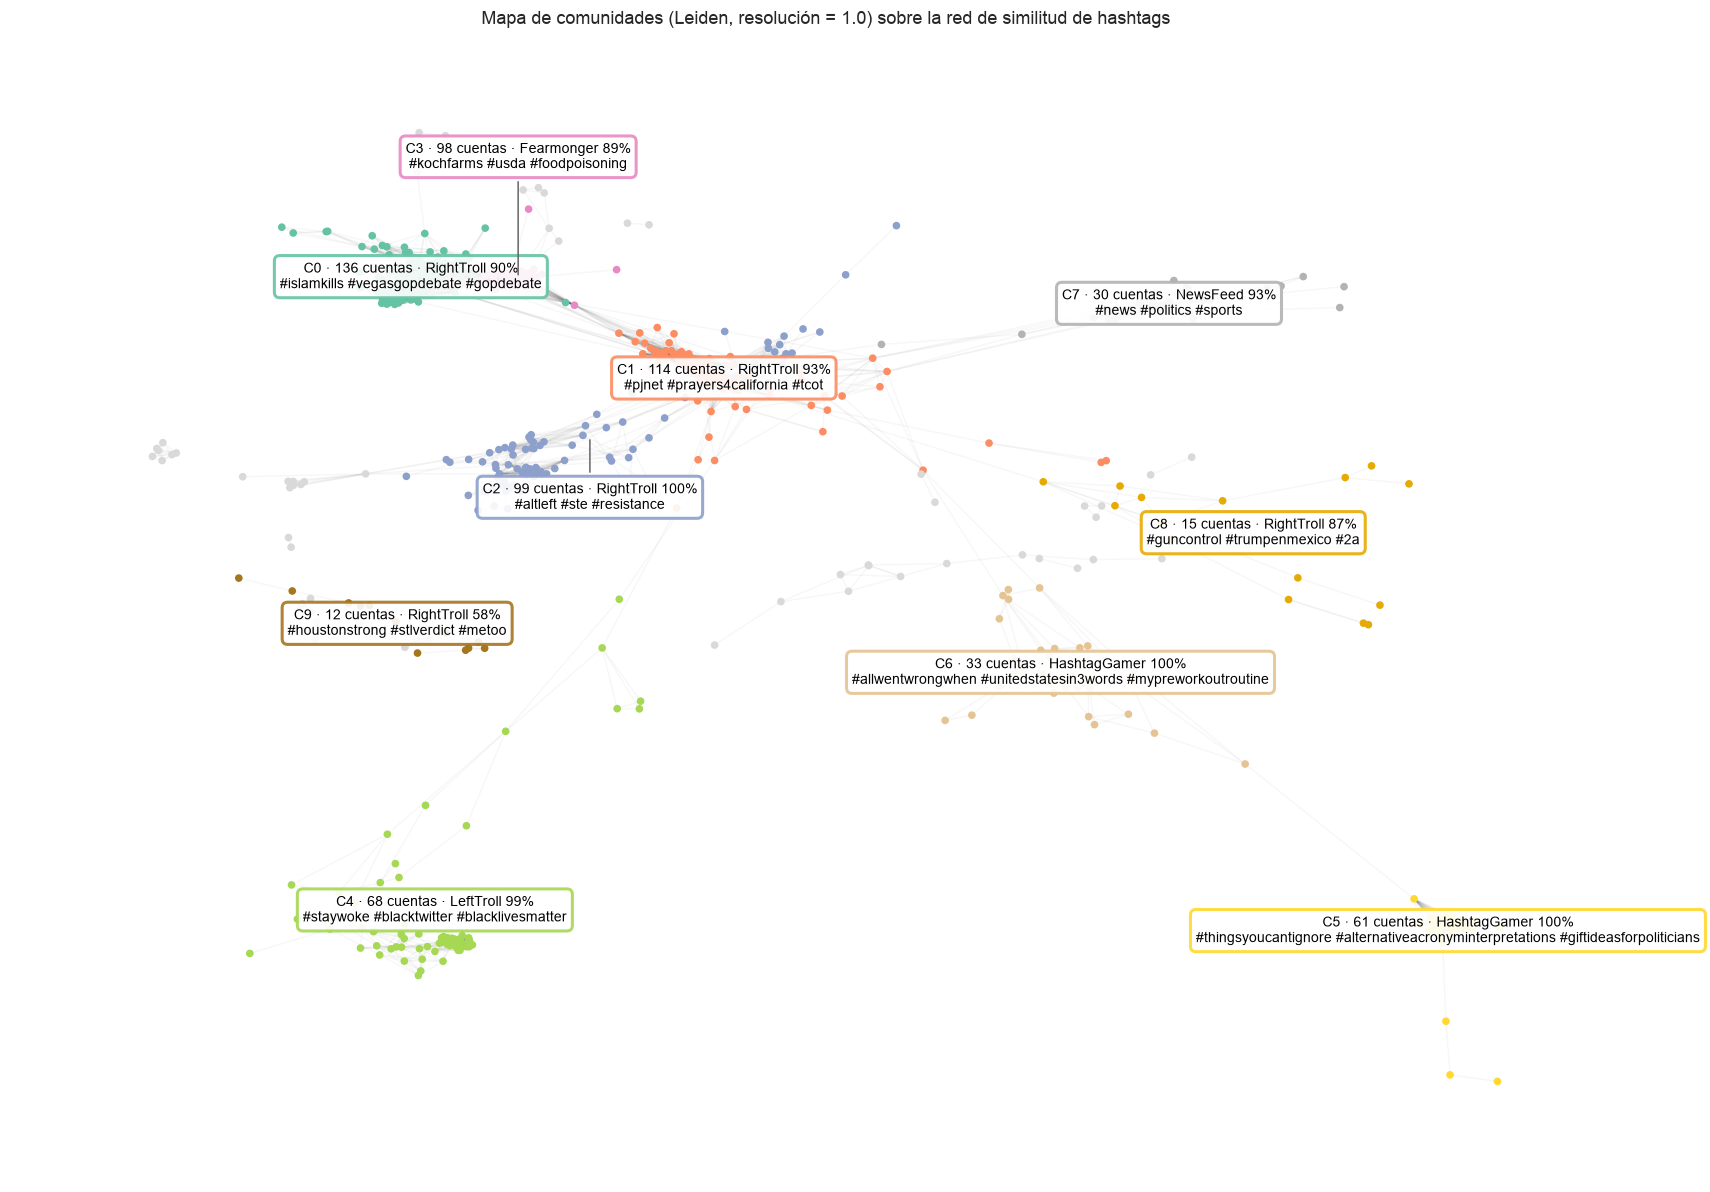

In [ ]:
TOP_MAPA = 10
# Paleta distinta de la de categorías: aquí el color es la COMUNIDAD, no el personaje
paleta_lei = sns.color_palette("Set2", 8) + sns.color_palette("Dark2", 8)[5:7]
colores_lei = [paleta_lei[lei_de[n]] if lei_de[n] < TOP_MAPA else (0.85, 0.85, 0.85) for n in G]

fig, ax = plt.subplots(figsize=(16, 11))
nx.draw_networkx_edges(G, pos, alpha=0.03, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=16, node_color=colores_lei, ax=ax)

colocadas = []
for k, c in enumerate(leiden[:TOP_MAPA]):
    idx = [perfil.index.get_loc(n) for n in c]
    centroide = np.asarray(X[idx].mean(axis=0)).ravel()
    tags = " ".join(nombres_vocab[centroide.argsort()[::-1][:3]])
    dominante = perfil.loc[list(c), "cat"].value_counts()
    xy = np.mean([pos[n] for n in c], axis=0)
    x = xy[0]
    for dy in [0, 0.1, -0.1, 0.2, -0.2, 0.3, -0.3]:   # desplaza la etiqueta si choca con otra
        y = xy[1] + dy
        if not any(abs(x - px) < 0.5 and abs(y - py) < 0.1 for px, py in colocadas):
            break
    colocadas.append((x, y))
    ax.annotate(f"C{k} · {len(c)} cuentas · {dominante.index[0]} {dominante.iloc[0] / len(c):.0%}\n{tags}",
                xy, xytext=(x, y), ha="center", va="center", fontsize=9, color="black",
                arrowprops=dict(arrowstyle="-", color="0.4") if y != xy[1] else None,
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=paleta_lei[k], lw=2, alpha=0.9))
ax.set_title(f"Mapa de comunidades (Leiden, resolución = {RESOLUCION}) sobre la red de similitud de hashtags")
ax.axis("off"); plt.tight_layout(); plt.show()

### ✏️ Ejercicio 6
1. Prueba `RESOLUCION = 0.5` y `RESOLUCION = 2.0`. ¿Cuántas comunidades salen? Con resolución alta, ¿en qué **subcampañas** se rompe el bloque RightTroll?
2. Aplica Leiden a la **red de co-publicación** del bloque 7 (grafo `C`). ¿Coinciden las comunidades con las componentes conexas?

<details><summary>Pista</summary>

```python
for r in [0.5, 1.0, 2.0]:
    p = la.find_partition(g, la.RBConfigurationVertexPartition, weights="weight", resolution_parameter=r, seed=42)
    comms = [{g.vs[v]["_nx_name"] for v in c} for c in p]
    print(r, len(comms), round(nx.community.modularity(G, comms), 3))
```
</details>

In [ ]:
# Tu código aquí

## 7. La prueba de la coordinación: *copypasta* y co-publicación

El indicador más potente de **comportamiento inauténtico coordinado** (*Coordinated Inauthentic Behavior*, el término que usa Meta) es que **muchas cuentas publiquen exactamente el mismo texto a la vez**. Un usuario real puede coincidir con otro de vez en cuando, pero 40 cuentas con el mismo titular en el mismo cuarto de hora difícilmente.

### 7.1 Textos idénticos en múltiples cuentas
Normalizamos el texto (minúsculas, sin URLs, espacios colapsados) y buscamos **tweets originales** (no retweets) repetidos.

In [ ]:
en["texto_norm"] = (en["content"].str.lower()
                    .str.replace(r"https?://\S+", "", regex=True)
                    .str.replace(r"\s+", " ", regex=True).str.strip())
originales = en[en["post_type"].isna() & (en["texto_norm"].str.len() >= 40)]

copypasta = (originales.groupby("texto_norm")
             .agg(cuentas=("author", "nunique"), veces=("author", "size"),
                  categorias=("account_category", lambda s: ", ".join(sorted(set(s)))),
                  primera=("publish_date", "min"), ultima=("publish_date", "max")))
copypasta["duración"] = copypasta["ultima"] - copypasta["primera"]
copypasta = copypasta[copypasta["cuentas"] >= 3].sort_values("cuentas", ascending=False)
print(f"{len(copypasta):,} textos publicados por 3 o más cuentas distintas")
copypasta.head(15)

16,418 textos publicados por 3 o más cuentas distintas


,cuentas,veces,categorias,primera,ultima,duración
texto_norm,,,,,,
newsone now audio podcast: bishop e.w. jackson calls #blacklivesmatter is movement “disgraceful”,88,217,"LeftTroll, RightTroll",2016-02-05 13:49:00,2016-06-20 15:09:00,136 days 01:20:00
get $0.05 for every download. $5.00 for every biz. #blackowned #buyblack #blacktwitter,50,83,LeftTroll,2016-02-19 08:33:00,2016-03-17 14:04:00,27 days 05:31:00
5 teens who did the unthinkable now face charges!,42,42,RightTroll,2017-07-22 08:10:00,2017-07-22 08:27:00,0 days 00:17:00
how racism causes post traumatic stress disorder (ptsd) #health #racism #wellness #blacklivesmatter,42,60,"LeftTroll, RightTroll",2016-02-05 13:54:00,2016-06-17 14:53:00,133 days 00:59:00
lindsay graham just doomed his re-election bid!,42,42,RightTroll,2017-07-22 08:10:00,2017-07-22 08:27:00,0 days 00:17:00
liar susan rice gives flimsy excuse to senate intelligence committee,40,40,RightTroll,2017-07-22 08:15:00,2017-07-22 08:29:00,0 days 00:14:00
#newhampshirefortrump #makeamericagreatagain #trump2016 #teamtrump #trumptrain #trumparmy #altright #ccot #tcot,34,47,RightTroll,2016-02-04 14:36:00,2016-02-18 11:41:00,13 days 21:05:00
i just activated @tweet_delete on my account to automatically delete my old tweets (,33,33,"Fearmonger, LeftTroll, RightTroll",2015-11-27 12:16:00,2015-11-30 09:41:00,2 days 21:25:00
rt @thehill: trump repeatedly interrupted by protesters shouting #blacklivesmatter,31,41,"LeftTroll, RightTroll",2016-02-08 13:23:00,2016-06-17 17:17:00,130 days 03:54:00


In [ ]:
# Textos idénticos publicados por trolls de IZQUIERDA y de DERECHA
ambos = copypasta[copypasta["categorias"].str.contains("LeftTroll") & copypasta["categorias"].str.contains("RightTroll")]
print(f"{len(ambos)} textos compartidos por ambos 'bandos'")
ambos.head(8)

2457 textos compartidos por ambos 'bandos'


,cuentas,veces,categorias,primera,ultima,duración
texto_norm,,,,,,
newsone now audio podcast: bishop e.w. jackson calls #blacklivesmatter is movement “disgraceful”,88,217,"LeftTroll, RightTroll",2016-02-05 13:49:00,2016-06-20 15:09:00,136 days 01:20:00
how racism causes post traumatic stress disorder (ptsd) #health #racism #wellness #blacklivesmatter,42,60,"LeftTroll, RightTroll",2016-02-05 13:54:00,2016-06-17 14:53:00,133 days 00:59:00
i just activated @tweet_delete on my account to automatically delete my old tweets (,33,33,"Fearmonger, LeftTroll, RightTroll",2015-11-27 12:16:00,2015-11-30 09:41:00,2 days 21:25:00
rt @thehill: trump repeatedly interrupted by protesters shouting #blacklivesmatter,31,41,"LeftTroll, RightTroll",2016-02-08 13:23:00,2016-06-17 17:17:00,130 days 03:54:00
rt @rnrillinois: remember kids. dont do cnn. its a gateway station that leads to other liberal media. #rednationrising #tcot #pjnet https:/…,26,29,"LeftTroll, RightTroll",2016-05-12 17:21:00,2016-05-29 01:32:00,16 days 08:11:00
rt @hcamp108: @opalayo #blacklivesmatter even in #venezuela make your own conclusions just watch [video],20,24,"LeftTroll, RightTroll",2016-02-08 13:33:00,2016-06-17 16:40:00,130 days 03:07:00
a movie made us wanna #changetheworld. here's why #inspiring #mlk #justice #blacklivesmatter,19,21,"LeftTroll, RightTroll",2016-02-05 15:05:00,2016-06-17 13:51:00,132 days 22:46:00
rt @hannahkauthor: some media are showing(manipulating and controlling) #election2016 polls to confuse voters? #tgdn #pjnet #tcot,19,19,"LeftTroll, RightTroll",2016-05-28 22:09:00,2016-05-29 02:54:00,0 days 04:45:00


### 7.2 Caso de estudio: una ráfaga sincronizada
Buscamos los textos copiados por muchas cuentas **en menos de una hora** y dibujamos el instante exacto de cada publicación.

2190 textos publicados por ≥ 20 cuentas en menos de 1 hora


,cuentas,veces,categorias,primera,ultima,duración
texto_norm,,,,,,
5 teens who did the unthinkable now face charges!,42,42,RightTroll,2017-07-22 08:10:00,2017-07-22 08:27:00,0 days 00:17:00
lindsay graham just doomed his re-election bid!,42,42,RightTroll,2017-07-22 08:10:00,2017-07-22 08:27:00,0 days 00:17:00
liar susan rice gives flimsy excuse to senate intelligence committee,40,40,RightTroll,2017-07-22 08:15:00,2017-07-22 08:29:00,0 days 00:14:00
video: former nfl fan burns pricey colts season tickets!,24,24,RightTroll,2017-09-27 12:09:00,2017-09-27 12:56:00,0 days 00:47:00
video: crowd boos loudly as entire cowboys team takes a knee,24,24,RightTroll,2017-09-26 13:51:00,2017-09-26 14:04:00,0 days 00:13:00
hollywood libs express their love for traitor mccain,24,24,RightTroll,2017-09-23 16:01:00,2017-09-23 16:06:00,0 days 00:05:00


Episodio del 22/07/2017: 6 textos, 42 cuentas


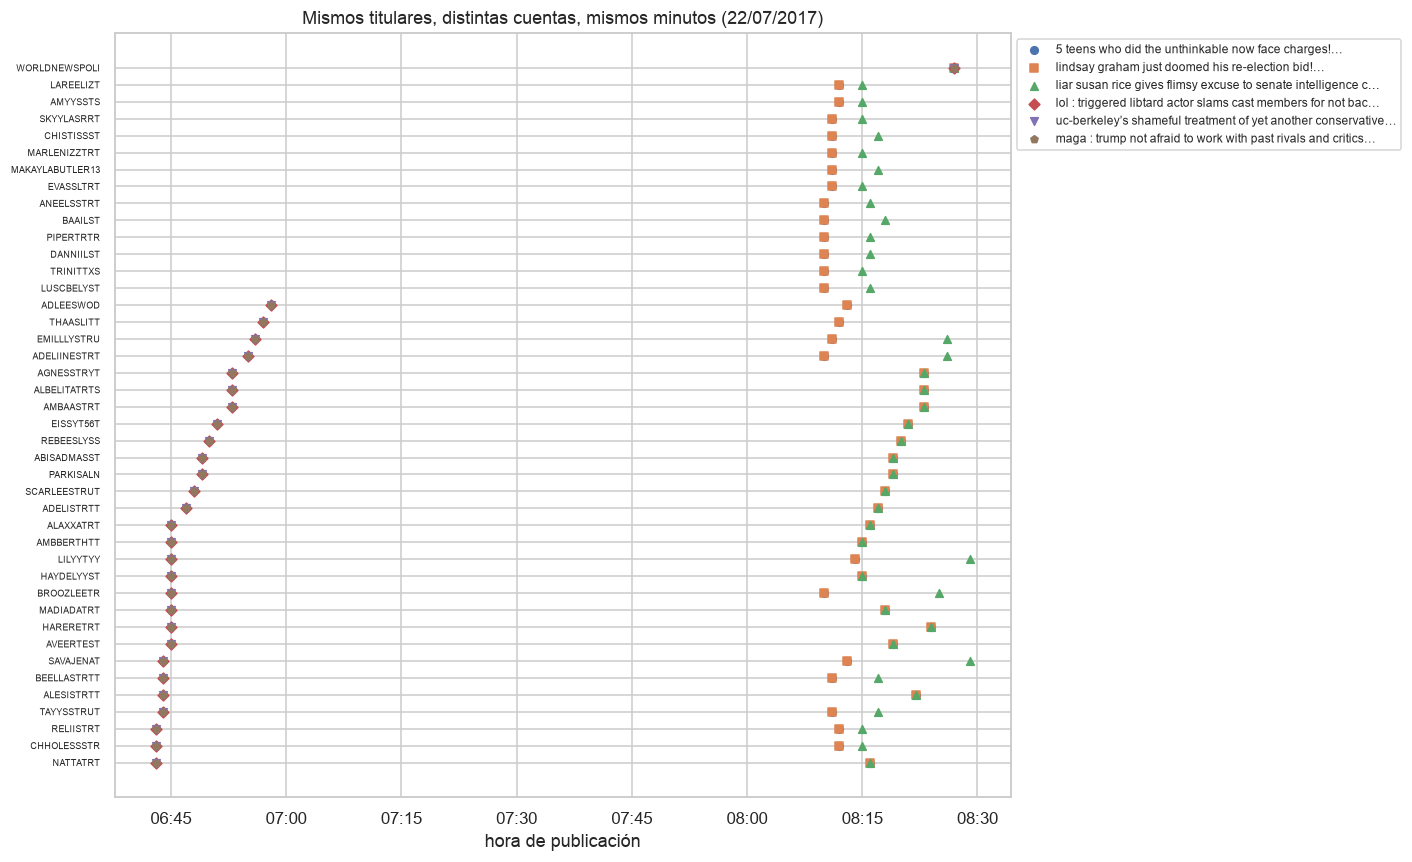

In [ ]:
rafagas = copypasta[(copypasta["duración"] < pd.Timedelta("1h")) & (copypasta["cuentas"] >= 20)]
print(f"{len(rafagas)} textos publicados por ≥ 20 cuentas en menos de 1 hora")
display(rafagas.head(6))

dia_caso = rafagas["primera"].iloc[0].date()   # el episodio con más cuentas implicadas
textos = copypasta[(copypasta["primera"].dt.date == dia_caso) & (copypasta["cuentas"] >= 20)].index
caso = originales[originales["texto_norm"].isin(textos) & (originales["publish_date"].dt.date == dia_caso)]
print(f"Episodio del {dia_caso:%d/%m/%Y}: {len(textos)} textos, {caso['author'].nunique()} cuentas")
orden = caso.groupby("author")["publish_date"].min().sort_values().index

fig, ax = plt.subplots(figsize=(13, 8))
for k, t in enumerate(textos):
    s = caso[caso["texto_norm"] == t]
    ax.scatter(s["publish_date"], s["author"].map({a: i for i, a in enumerate(orden)}),
               s=25, label=t[:60] + "…", marker="os^Dvp"[k])
ax.set_yticks(range(len(orden))); ax.set_yticklabels(orden, fontsize=6)
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("hora de publicación"); ax.set_title(f"Mismos titulares, distintas cuentas, mismos minutos ({dia_caso:%d/%m/%Y})")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.show()

> Decenas de cuentas que fingen ser personas independientes publican **los mismos titulares en dos oleadas de pocos minutos**:
> * En la **primera oleada (06:43-06:58)** las cuentas publican **una tras otra, minuto a minuto, en escalera**, como si un programa las recorriera en orden.
> * Fíjate en los **nombres de usuario**: `NATTATRT`, `CHHOLESSSTR`, `ALESISTRTT`, `AGNESSTRYT`... Parecen **generados en serie** con un nombre femenino y un sufijo aleatorio. Analizar los *handles* es otra técnica clásica de SOCMINT. Es la huella típica de una **herramienta de publicación automatizada** que gestiona muchas cuentas a la vez.

### 7.3 Red de co-publicación
Generalizamos la idea: **dos cuentas quedan unidas si publican el mismo texto dentro de la misma ventana de 10 minutos**. El peso de la arista es cuántas veces ocurre. Nos quedamos con las parejas que coinciden al menos 3 veces, para filtrar coincidencias casuales.

In [ ]:
VENTANA = "10min"   # <- parámetro a explorar
MIN_COINCIDENCIAS = 3

o = originales[["author", "texto_norm", "publish_date"]].copy()
o["ventana"] = o["publish_date"].dt.floor(VENTANA)
grupos = o.groupby(["texto_norm", "ventana"])["author"].agg(lambda s: sorted(set(s)))
grupos = grupos[grupos.map(len) >= 2]

C = nx.Graph()
for cuentas in grupos:
    for u, v in combinations(cuentas, 2):
        w = C[u][v]["weight"] + 1 if C.has_edge(u, v) else 1
        C.add_edge(u, v, weight=w)
C = nx.Graph([(u, v, d) for u, v, d in C.edges(data=True) if d["weight"] >= MIN_COINCIDENCIAS])
nx.set_node_attributes(C, cat_de[list(C.nodes)].to_dict(), "cat")
print(C)

componentes = sorted(nx.connected_components(C), key=len, reverse=True)
pd.DataFrame([{"tamaño": len(c), "composición": pd.Series([C.nodes[n]["cat"] for n in c]).value_counts().to_dict()}
              for c in componentes[:10]])

Graph with 307 nodes and 1168 edges


,tamaño,composición
0,107,"{'RightTroll': 81, 'NewsFeed': 26}"
1,37,{'RightTroll': 37}
2,18,"{'Fearmonger': 14, 'RightTroll': 3, 'NewsFeed': 1}"
3,17,{'HashtagGamer': 17}
4,12,{'RightTroll': 12}
5,11,{'LeftTroll': 11}
6,7,{'LeftTroll': 7}
7,6,{'RightTroll': 6}
8,5,{'LeftTroll': 5}
9,4,"{'RightTroll': 3, 'LeftTroll': 1}"


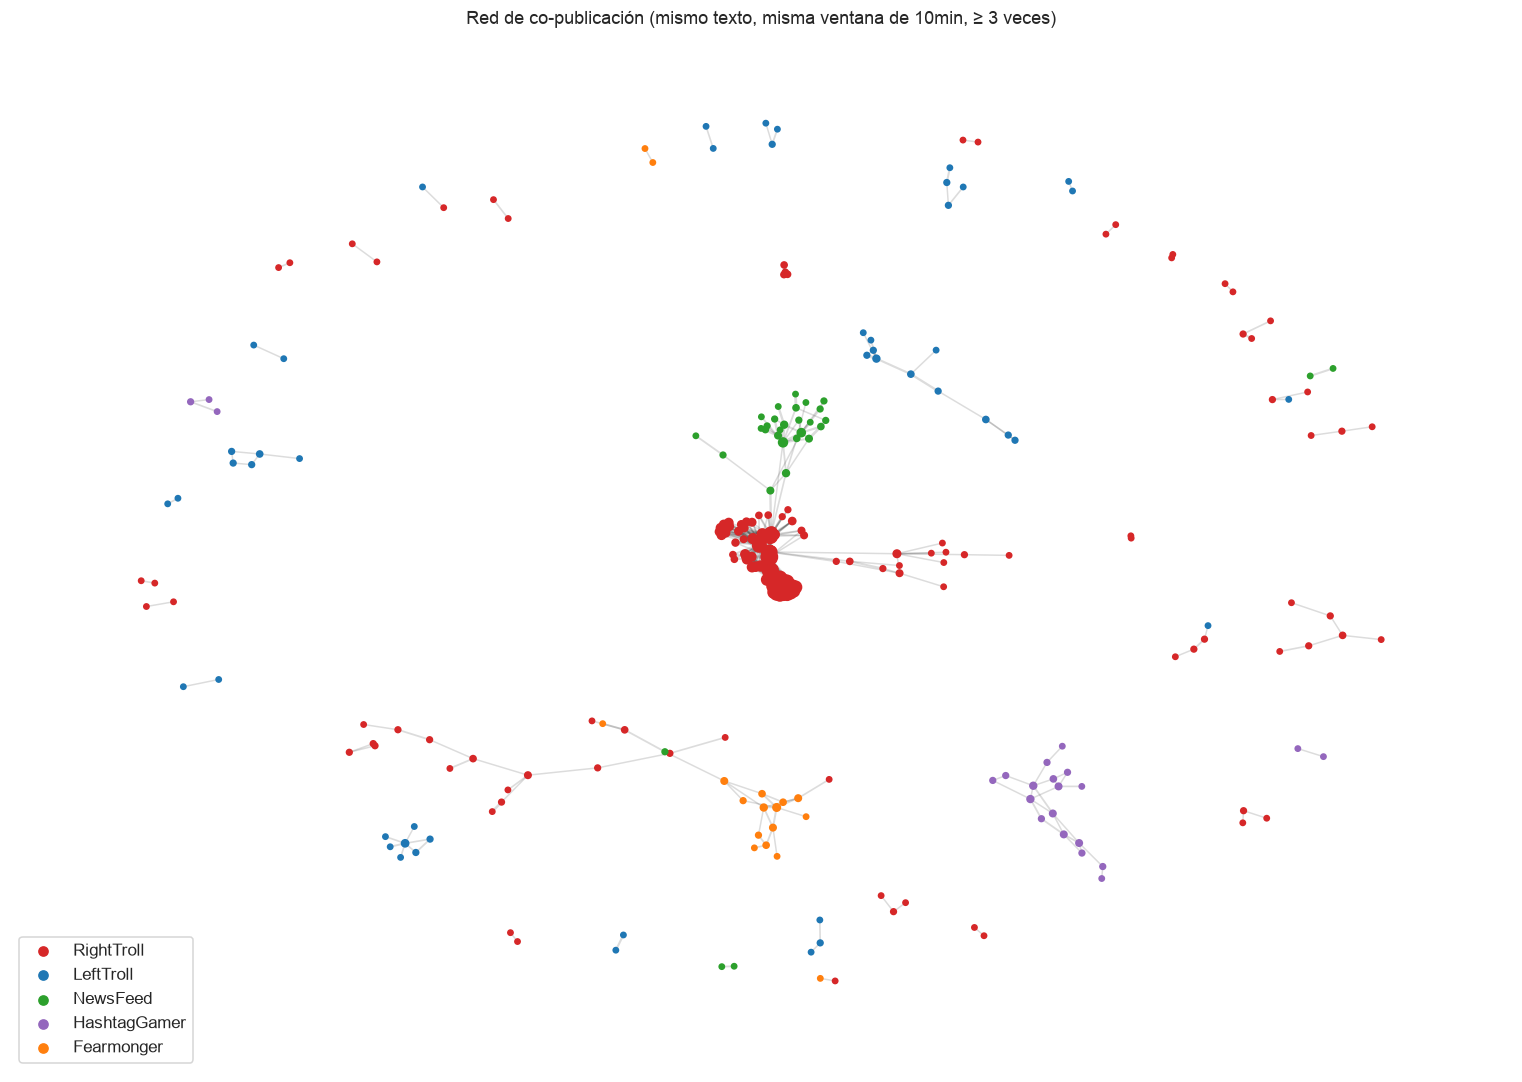

In [ ]:
pos = nx.spring_layout(C, k=0.15, iterations=80, seed=3)
fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(C, pos, alpha=0.15, width=[0.3 + np.log1p(d["weight"]) / 2 for *_, d in C.edges(data=True)], ax=ax)
nx.draw_networkx_nodes(C, pos, node_size=[10 + 2 * C.degree(n) for n in C],
                       node_color=[COLORES[C.nodes[n]["cat"]] for n in C], ax=ax)
for c in CATS:
    ax.scatter([], [], c=COLORES[c], label=c)
ax.legend(loc="lower left"); ax.axis("off")
ax.set_title(f"Red de co-publicación (mismo texto, misma ventana de {VENTANA}, ≥ {MIN_COINCIDENCIAS} veces)")
plt.tight_layout(); plt.show()

> **Observa:** la componente más grande mezcla **RightTroll** (personajes de "patriotas") y **NewsFeed** (falsos periódicos locales). Para el público eran fuentes independientes que se confirmaban unas a otras, pero publicaban lo mismo, a la vez, desde la misma maquinaria. Así se fabrica la ilusión de consenso (*astroturfing*).

### 7.4 Exportar la red para explorarla de forma interactiva
Generamos un HTML que se puede abrir en el navegador. Permite arrastrar nodos, hacer zoom y ver el nombre de cada cuenta.

In [ ]:
from pyvis.network import Network

net = Network(height="750px", width="100%", bgcolor="#ffffff", cdn_resources="in_line")
for n in C.nodes:
    net.add_node(n, label=n, color=COLORES[C.nodes[n]["cat"]], title=f"{n} · {C.nodes[n]['cat']}",
                 size=5 + C.degree(n) ** 0.7)
for u, v, d in C.edges(data=True):
    net.add_edge(u, v, value=d["weight"], title=f"{d['weight']} coincidencias")
net.barnes_hut(gravity=-4000, spring_length=120)
net.write_html(str(SALIDAS / "red_coordinacion.html"), notebook=False)
print("Abre en el navegador:", (SALIDAS / "red_coordinacion.html").resolve())

if EN_COLAB:   # en Colab no hay navegador local: mostramos la red aquí mismo
    from IPython.display import HTML, display
    display(HTML((SALIDAS / "red_coordinacion.html").read_text()))

Abre en el navegador: /Users/chamoso/Desktop/taller_socmint/salidas/red_coordinacion.html


### ✏️ Ejercicio 5
1. Cambia `VENTANA` a `"1min"` y a `"1h"`. ¿Cómo cambia el tamaño de la red? ¿Qué ventana da más **falsos positivos** y cuál deja fuera más coordinación real?
2. En el mundo real **no tendrías solo cuentas troll**: también usuarios auténticos que comparten el mismo titular de un medio. ¿Qué filtros añadirías para no acusar a usuarios legítimos? (Piensa en: textos muy cortos o genéricos, retweets, frases hechas, botones de "compartir" de las webs de noticias...)

In [ ]:
# Tu código aquí

## 8. Reto final (opcional): ¿un clasificador de personajes?

Si las categorías dejan huellas tan claras, un modelo debería poder **predecir la categoría de una cuenta** a partir de lo que escribe. Esto es la base de muchos detectores de operaciones de influencia.

**Reto:** entrena una regresión logística sobre el TF-IDF de los hashtags de cada cuenta (`X`, `perfil["cat"]`) con validación cruzada. ¿Qué *accuracy* obtienes? ¿Qué categorías confunde? ¿Qué hashtags pesan más para cada clase?

<details><summary>Solución</summary>

```python
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

clf = LogisticRegression(max_iter=2000, class_weight="balanced")
pred = cross_val_predict(clf, X, perfil["cat"], cv=5)
print(classification_report(perfil["cat"], pred))
ConfusionMatrixDisplay.from_predictions(perfil["cat"], pred, xticks_rotation=45)

clf.fit(X, perfil["cat"])
for k, c in enumerate(clf.classes_):
    print(c, "→", " ".join(nombres_vocab[clf.coef_[k].argsort()[::-1][:10]]))
```
**Para discutir:** un buen resultado aquí **no** significa que tengamos un detector de trolls. El modelo distingue *tipos de troll entre sí*, no trolls de usuarios reales. ¿Qué datos harían falta para eso?
</details>

In [ ]:
# Tu código aquí

## 9. Conclusiones y limitaciones

**Qué hemos visto:**
1. **Temporalidad:** la actividad responde a una agenda, con picos sincronizados en fechas clave.
2. **Huella operativa:** menos actividad en fin de semana y el mismo horario en bandos opuestos. Parece una oficina, no una comunidad de usuarios.
3. **Polarización a dos bandas:** la misma organización alimentaba los dos lados del mismo debate (#BlackLivesMatter).
4. **Segmentación de audiencias:** cada personaje se dirigía a un público concreto (análisis de menciones).
5. **Detección no supervisada:** con solo los hashtags, Louvain y Leiden recuperan los personajes y revelan subcampañas.
6. **Coordinación:** textos idénticos publicados en los mismos minutos por cuentas que fingían ser independientes.

**Limitaciones que un analista debe tener presentes:**
* **Sesgo de selección:** solo vemos las cuentas que Twitter detectó. Las mejores operaciones son las que **no** están en el dataset.
* **Etiquetas imperfectas:** las categorías son una interpretación humana; una cuenta puede cambiar de personaje.
* **Zona horaria** de las marcas de tiempo no documentada.
* **Faltan metadatos:** no sabemos qué cuenta original se retuiteaba, ni las IP, ni la fecha de creación de las cuentas. Las plataformas tienen esos datos y los investigadores externos no.
* **Correlación ≠ atribución:** la coordinación demuestra que hay un operador común, **no quién es**. La atribución a la IRA vino de fuentes adicionales (inteligencia, investigaciones judiciales, datos internos de la plataforma).

## 10. Referencias
* Linvill, D. L. y Warren, P. L. (2020). *Troll Factories: Manufacturing Specialized Disinformation on Twitter*. **Political Communication**, 37(4), 447-467.
* Roeder, O. (2018). *Why We're Sharing 3 Million Russian Troll Tweets*. FiveThirtyEight. Datos: <https://github.com/fivethirtyeight/russian-troll-tweets>
* Mueller, R. S. (2019). *Report on the Investigation into Russian Interference in the 2016 Presidential Election*, Vol. I, sección II ("Russian 'Active Measures' Social Media Campaign").
* Pacheco, D. et al. (2021). *Uncovering Coordinated Networks on Social Media: Methods and Case Studies*. **ICWSM**.
* Blondel, V. D. et al. (2008). *Fast unfolding of communities in large networks*. **J. Stat. Mech.** (algoritmo de Louvain).
* Traag, V. A., Waltman, L. y van Eck, N. J. (2019). *From Louvain to Leiden: guaranteeing well-connected communities*. **Scientific Reports**, 9, 5233.
* DiResta, R. et al. (2018). *The Tactics & Tropes of the Internet Research Agency*. New Knowledge, para el Senado de EE. UU.